In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
import numpy as np
import os

In [ ]:
import zipfile

zip_path = '/content/datasetnolb.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'File berhasil diekstrak ke {extract_path}')

File berhasil diekstrak ke /content/


In [ ]:
image_dir = '/content/datasetnolb'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0

        label = int(filename.split('.')[0])

        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

history = model.fit(
    X, y,
    epochs=500,
    batch_size=32,
    callbacks=[checkpoint]
)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 468653.1875 - mae: 647.9023
Epoch 1: loss improved from inf to 468653.18750, saving model to best_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 468653.1875 - mae: 647.9023
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 448376.4688 - mae: 632.4473
Epoch 2: loss improved from 468653.18750 to 448376.46875, saving model to best_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 448376.4688 - mae: 632.4473
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 398365.1250 - mae: 592.5906
Epoch 3: loss improved from 448376.46875 to 398365.12500, saving model to best_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 398365.1250 - mae: 592.5906
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 304805.0625 - mae: 509.6626
Epoch 4: loss improved from 398365.12500 to 304805.06250, saving model to best_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 304805.0625 - mae: 509.6626
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - loss: 168077.1250 - mae: 355.5603
Epoch 5: loss improved from 304805.06250 to 168077.12500, saving model to best_model.h5


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 4.8894e-09 - mae: 6.8665e-05   
Epoch 280/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - loss: 5.1223e-08 - mae: 1.9836e-04
Epoch 280: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step - loss: 5.1223e-08 - mae: 1.9836e-04
Epoch 281/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - loss: 7.9395e-08 - mae: 2.5177e-04
Epoch 281: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step - loss: 7.9395e-08 - mae: 2.5177e-04
Epoch 282/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - loss: 2.6310e-08 - mae: 1.4496e-04
Epoch 282: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step - loss: 2.6310e-08 - mae: 1.4496e-04
Epoch 283/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - loss: 1.0245e-08 - mae: 7.6294e-05
Epoch 283: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step - loss: 1.0245e-08 - mae: 7.6294e-05
Epoch 284/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 5.7975e-08 - mae: 2.21

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 989ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 306/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 306: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 943ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 307/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 3.7253e-09 - mae: 6.1035e-05
Epoch 307: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 3.7253e-09 - mae: 6.1035e-05
Epoch 308/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 308: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 309/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 3.7253e-09 - mae: 6.1035e-05
Epoch 309: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 3.7253e-09 - mae: 6.1035e-05
Epoch 310/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - loss: 3.7253e-09 - mae: 6.1035e-05
Ep

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 997ms/step - loss: 1.8626e-09 - mae: 3.0518e-05
Epoch 314/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - loss: 5.5879e-09 - mae: 6.1035e-05
Epoch 314: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step - loss: 5.5879e-09 - mae: 6.1035e-05
Epoch 315/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - loss: 2.7940e-09 - mae: 4.5776e-05
Epoch 315: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step - loss: 2.7940e-09 - mae: 4.5776e-05
Epoch 316/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 877ms/step - loss: 2.0955e-09 - mae: 3.8147e-05
Epoch 316: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step - loss: 2.0955e-09 - mae: 3.8147e-05
Epoch 317/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 2.7940e-09 - mae: 4.5776e-05
Epoch 317: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 2.7940e-09 - mae: 4.5776e-05
Epoch 318/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - loss: 3.0268e-09 - mae: 5.3406e

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step - loss: 1.1642e-09 - mae: 2.2888e-05
Epoch 331/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 331: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 959ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 332/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 332: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 943ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 333/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - loss: 2.0955e-09 - mae: 3.8147e-05
Epoch 333: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 992ms/step - loss: 2.0955e-09 - mae: 3.8147e-05
Epoch 334/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - loss: 2.0955e-09 - mae: 3.8147e-05
Epoch 334: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step - loss: 2.0955e-09 - mae: 3.8147e-05
Epoch 335/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - loss: 2.0955e-09 - mae: 3

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0000e+00 - mae: 0.0000e+00
Epoch 345/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 345: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 346/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 346: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step - loss: 3.0268e-09 - mae: 5.3406e-05
Epoch 347/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - loss: 2.0955e-09 - mae: 3.8147e-05
Epoch 347: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step - loss: 2.0955e-09 - mae: 3.8147e-05
Epoch 348/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 2.0955e-09 - mae: 3.8147e-05
Epoch 348: loss did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 2.0955e-09 - mae: 3.8147e-05
Epoch 349/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 2.0955e-09 - mae: 3.8147e-05
Ep

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


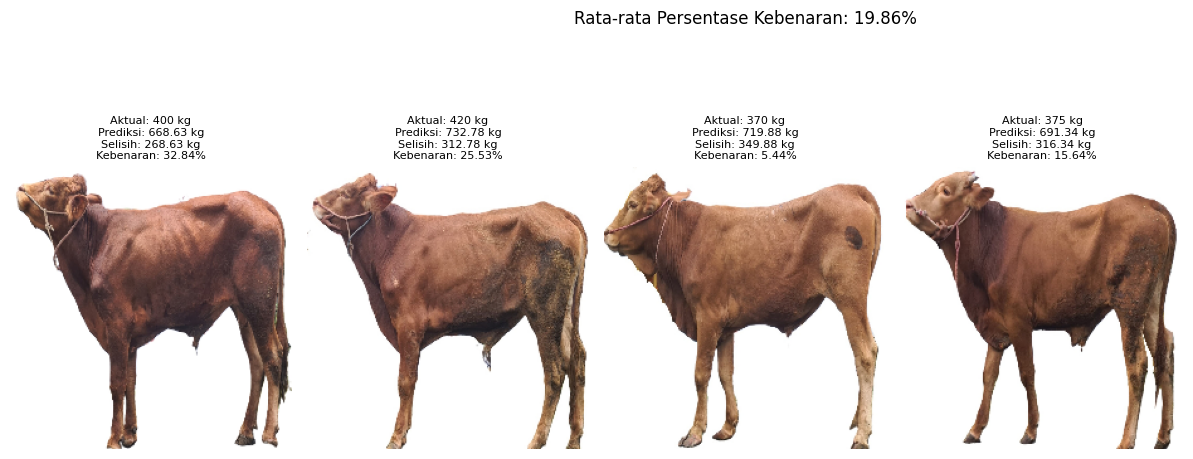

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/test.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/test'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0

        label = int(filename.split('.')[0])

        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)


best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)


num_images = len(X)
cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step


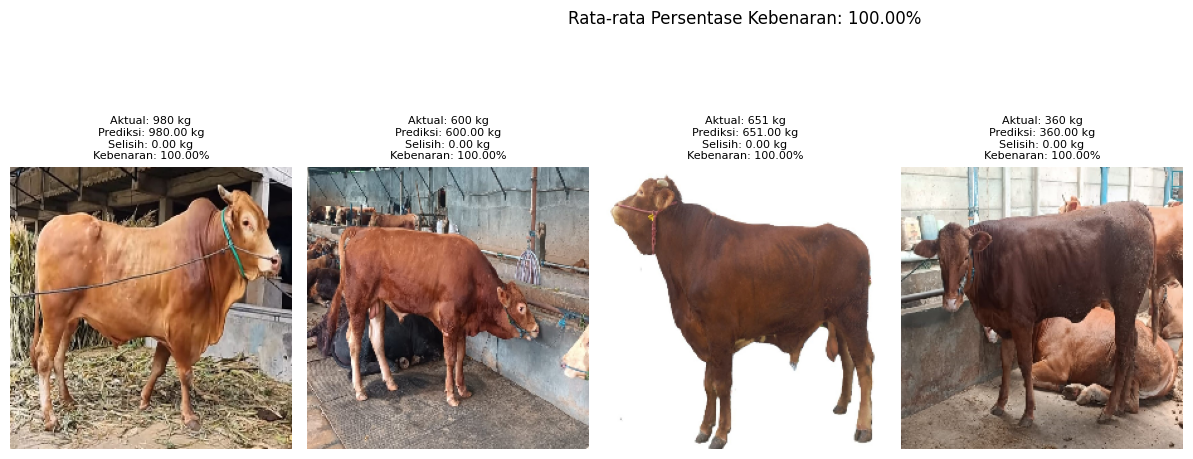

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/datasetnolb.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/datasetnolb'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0

        label = int(filename.split('.')[0])

        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)


best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)


num_images = len(X)
cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

File berhasil diekstrak ke /content/


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step


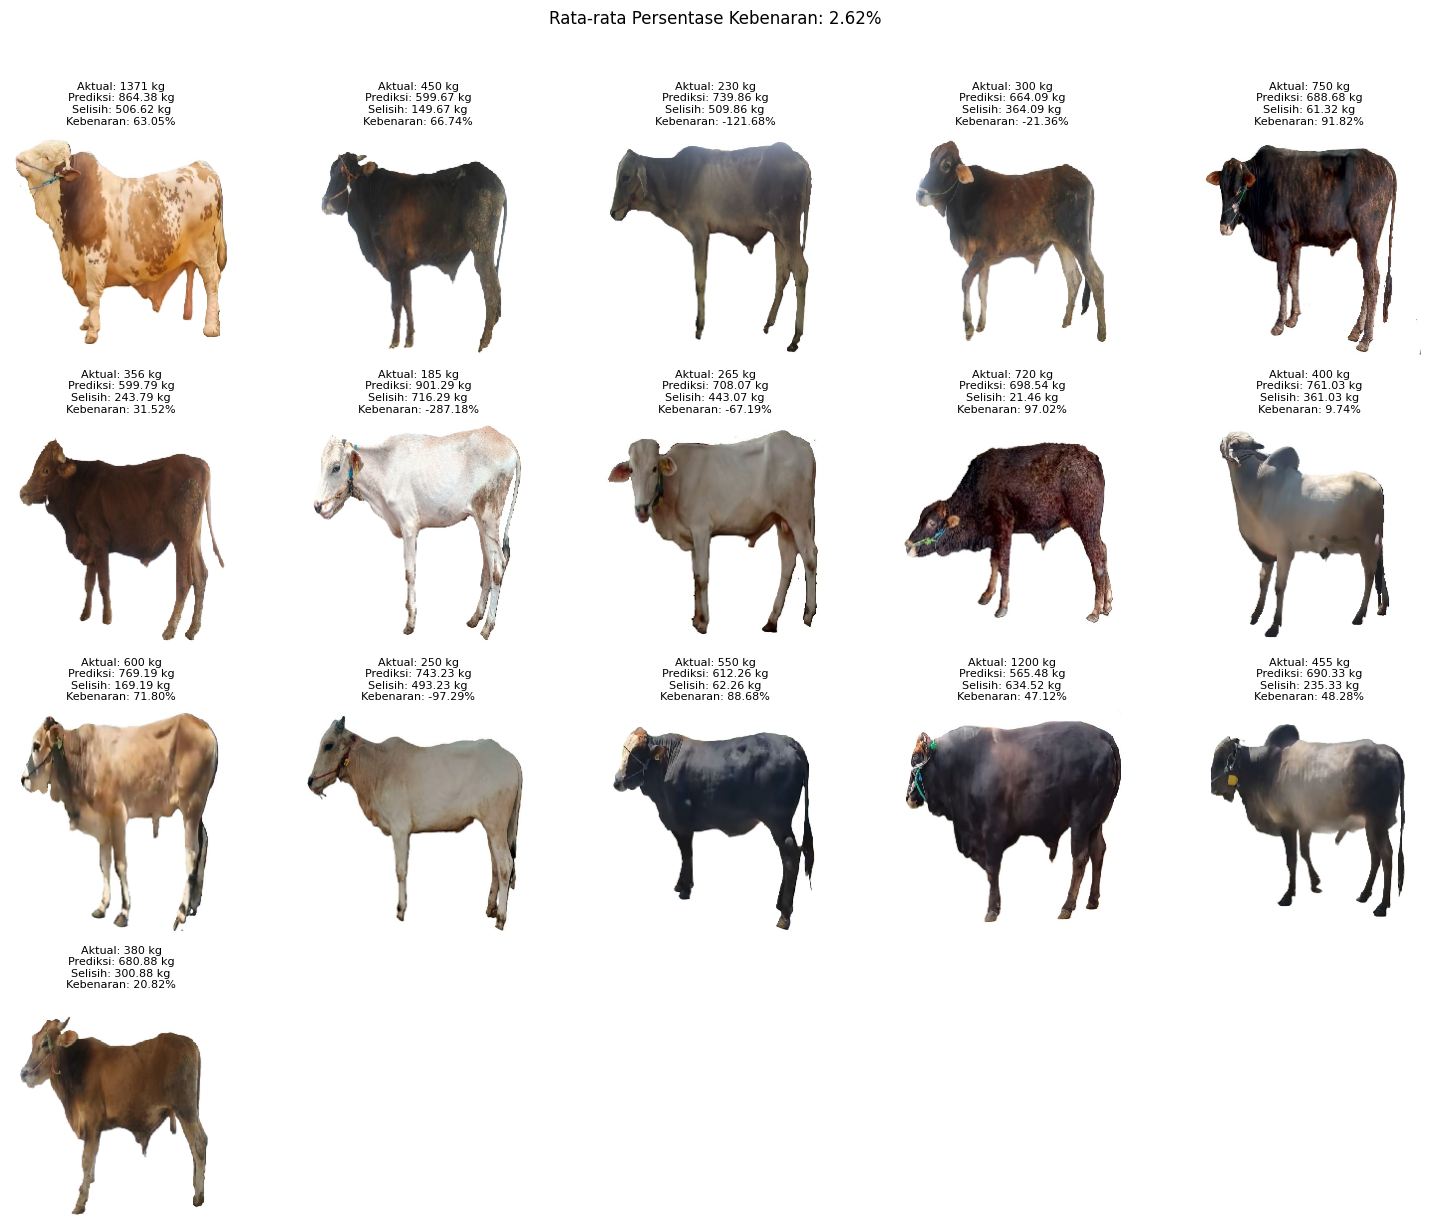

In [ ]:
import zipfile
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import math

test_zip_path = '/content/test_dataset.zip'
test_extract_path = '/content/'

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_path)

print(f'File berhasil diekstrak ke {test_extract_path}')

image_dir = '/content/test_dataset'

images = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith(".jpg"):
        img_path = os.path.join(image_dir, filename)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0

        label = int(filename.split('.')[0])

        images.append(img_array)
        labels.append(label)

X = np.array(images)
y = np.array(labels)


best_model = tf.keras.models.load_model('best_model.h5')
prediksi_bobot = best_model.predict(X)
selisih = np.abs(y - prediksi_bobot.flatten())
persentase_kebenaran = 100 * (1 - selisih / y)
rata_rata_persentase = np.mean(persentase_kebenaran)


num_images = len(X)
cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[i])
    plt.axis('off')
    plt.title(f"Aktual: {y[i]} kg\nPrediksi: {prediksi_bobot[i][0]:.2f} kg\nSelisih: {selisih[i]:.2f} kg\nKebenaran: {persentase_kebenaran[i]:.2f}%", fontsize=8, color='black')

plt.suptitle(f"Rata-rata Persentase Kebenaran: {rata_rata_persentase:.2f}%", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()